# PA 1 – Part B: The Word Embeddings Quest

Welcome, intrepid adventurer, to your hands-on mission into the realm of **word embeddings**, also known as **word vectors**, **semantic vectors**, or **dense representations**. In this quest, you will train your own embeddings using the powerful **SGNS** algorithm (**Skip-gram with Negative Sampling**) and uncover the hidden structure of language lurking within the text.


## The Magic of Word Embeddings

Think of each word as a tiny creature in a vast linguistic universe. **Word embeddings** capture the essence of these creatures by mapping them into a dense vector space. Unlike simple codes or one-hot labels, a word’s meaning is **distributed across all dimensions** of its vector. Each dimension contributes a small clue, and only by looking at the full pattern can we understand the word’s true nature.  

Because these dimensions are shared among words, creatures with similar traits cluster together. This shared, spread-out encoding is called a **distributed representation**, and it allows models to perceive semantic similarity and uncover hidden relationships between words.


## Why This Mission Matters

By mastering distributed word representations, you gain the power to:  
- Compress large vocabularies into compact, expressive vectors  
- Reveal subtle relationships between words that go beyond exact matches  
- Lay the foundation for modern NLP systems that understand meaning, context, and nuance  


## Your Mission Objectives

1. **Master the Learning of Distributed Representations:** Use **Word2Vec (Skip-gram with Negative Sampling)** to extract hidden meaning from text.  
2. **Forge Your Own Word Embeddings:** Train vectors that capture semantic and syntactic relationships between words.  
3. **Test Your Linguistic Insight:** Evaluate the embeddings through **analogy tasks** and **bias measurement**, discovering both the powers and limitations of your learned vectors.  




## Recommended Reading

1. Chapter 5 of [the SLP3 textbook](https://web.stanford.edu/~jurafsky/slp3)  
2. This [illustrated writeup by Jay Alammar](https://jalammar.github.io/illustrated-word2vec/)


## Instructions
- <font color="red">Proceed cell by cell and complete all sections where you are asked to write code.</font>
- <font color="red">Carefully read the course outline for the plagiarism policy and late-day rules.</font>
- <font color="red">Run all cells before submitting to receive full credit.</font>
- <font color="red">Do not delete or modify any pre-written code.</font>
- <font color="red">Attempt every part; each section builds toward a complete understanding.</font>
Failure to follow these rules may result in marks deduction.

## Submission Instructions
- <font color="red">Rename the notebook according to you Student ID. For example if you student ID is 27010001, rename the file to 27010001_PART_A</font>
- <font color="red">Once you're done with both Part A and Part B, zip the folder containing both notebooks and rename the folder to your Student ID as well.</font>


## Part 1 – The Word2Vec Expedition [30 points]

Your first hands-on mission begins here: implementing the legendary **`word2vec`** algorithm.  

`word2vec` is a **powerful framework** for uncovering hidden relationships between words, but in this quest, your focus will be the **Skip-gram model**, just as described in the iconic 2013 paper. To guide you through this adventure, your **primary map** is the lecture slides, with additional insights available in the recommended resources.  

For this expedition, your terrain will be one of the **most epic tales ever told**: <font color="red">~~Harry Potter and the Sorcerer’s Stone~~ </font><font color="teal">**_The Lord of the Rings_** </font>, starting with the first book, <font color="teal">**_The Fellowship of the Ring_**. </font>  

While the full text is a vast and magical landscape, training embeddings on it in its entirety could take far too long. Fear not! We will journey through a **carefully chosen excerpt**

Prepare your tools, adventurer, the path to mastering word embeddings begins now!


In [55]:
# Import in the libraries
# Note: you are NOT allowed to use any other libraries or functions outside of these
# Use the following seeds for reproducibility

import os
import re
import random
from typing import List, Union, Tuple
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

np.random.seed(42)
random.seed(42)

In the cell below, you will:
- Read the entire text file into **one long string** and store it in the variable `data`.  
- Print the **first 300 characters** of `data` to preview the content.  
- Print the **total number of characters** in `data` to check the file size.


In [ ]:
#Read in the data
with open("The Fellowship of the Ring.txt", "r", encoding="utf-8") as f:
    data = f.read()

print(data[:300]) 

print(f"Total number of characters in data: {len(data)}")

J. R. R. Tolkien  The Lord Of The Rings. (1/4)
-----------------------------------------------


     THE LORD OF THE RINGS

              by

     J. R. R. TOLKIEN



 Part 1: The Fellowship of the Ring
 Part 2: The Two Towers
 Part 3: The Return of the King


_Complete with Index and Full Appendi
Total number of characters in data: 1024531


Write the `Dataset` class from scratch. It must handle the cleaning, tokenization, and indexing of our text.

**Class Requirements:**

1.  **`__init__(self, data)`**:
    * **Clean the Runes:** First, substitute the punctuation characters `,` `!` `?` `;` `-` with a single period `.` to preserve sentence boundaries. (Hint: `re.sub` is your friend).
    * **Tokenize:** Split the text into individual tokens using `word_tokenize`.
    * **Purify:** Keep only tokens that are **alphabetic** OR are exactly a period `.`. Discard numbers and other symbols.
    * **Normalize:** Convert all tokens to **lowercase**.
    * **Build the Archives (Attributes):**
        * `tokens`: The list of all processed tokens.
        * `vocab`: A **sorted** list of unique tokens.
        * `vocab_size`: The total number of unique tokens.
        * `stoi`: A dictionary mapping **String to Index**.
        * `itos`: A dictionary mapping **Index to String**.

2.  **`__len__(self)`**:
    * Return the total number of tokens in the dataset.


---
- The two mappings `stoi` and `itos` will be helpful in fetching your Embeddings later on, since your Embeddings will be a matrix of shape `(vocab_size, embedding_dim)` and the ordering will be dependent on your vocabulary's ordering, that's why its important to sort your vocabulary to have consistent ordering.

In [ ]:
# Define the Dataset class
class Dataset:
#==================== CODE STARTS HERE ====================
  def __init__(self,data):
    cleaned_data = re.sub(r'[,!?;-]', '.', data)
    tokens = word_tokenize(cleaned_data)
    purified_tokens = [token for token in tokens if token.isalpha() or token == '.']
    lowercase_tokens = [token.lower() for token in purified_tokens]
    self.tokens = lowercase_tokens
    self.vocab = sorted(set(lowercase_tokens))
    self.vocab_size = len(self.vocab)
    self.stoi = {token: idx for idx, token in enumerate(self.vocab)}
    self.itos = {idx: token for idx, token in enumerate(self.vocab)}
  
  def __len__(self):
    return len(self.tokens)

#==================== CODE ENDS HERE ====================


#DO NOT MODIFY THE FOLLOWING CODE
dataset = Dataset(data)
print(f"Number of tokens in dataset: {len(dataset)}")
print(f"Vocabulary size: {dataset.vocab_size}")

Number of tokens in dataset: 210096
Vocabulary size: 8451


### The Sliding Window Strategy

To understand the true nature of a word, we cannot look at it in isolation. We must observe the company it keeps.



In the **Skip-gram** model, we slide a "window" over the text. The word in the middle is our **Center Word** (Target), and the words surrounding it are the **Context Words** (Outside).

<center>
<img src="https://jalammar.github.io/images/word2vec/skipgram-sliding-window-2.png">
</center>

**Your Mission:**
Implement the `get_windows` function to generate these training pairs.

**Function Requirements:**

1.  **`get_windows(data, ctx_size)`**:
    * **Inputs:**
        * `data`: A list of tokens (strings or integers).
        * `ctx_size`: An integer representing the radius of the window (how many words to the left and right).

    * **Returns:**
        * Two lists: `outside_words` (a list of lists, where each inner list contains the context tokens) and `center_words` (a list of the target tokens).

**Crucial:** Be careful with your loop range! You cannot start at index 0 or end at the very last index, as you need space for the context on both sides.



In [58]:
def get_windows(
        data: List[Union[str, int]],
        ctx_size: int
    ):
    """
    Generates sliding windows for dataset creation.

    This function iterates over the input data using a sliding window of total size
    `2 * ctx_size + 1`. For each valid position, it extracts the center word (target)
    and its surrounding neighbors (context).

    Args:
        data (List[Union[str, int]]): The input sequence of tokens (strings or indices).
        ctx_size (int): The context radius (number of words to the left and right of the center).

    Returns:
        Tuple[List, List]:
            - outside_words: A list of context lists (the surrounding words).
            - center_words: A list of target words (the center words).
    """

  #==================== CODE STARTS HERE ====================
    i = ctx_size
    output_words = []
    center_words = []
    while(i < len(data) - ctx_size):
        center_words.append(data[i])
        output_words.append(data[i-ctx_size:i] + data[i+1:i+ctx_size+1])
        i += 1
    return output_words, center_words


  #==================== CODE ENDS HERE ====================

**Verification:**
After implementing the function, test it using the provided "under the water" sentence below to ensure your window slides correctly.

In [59]:


test_sentence = "The quick brown fox jumps over the lazy dog."
ctx_size = 2
owords, cwords = get_windows(word_tokenize(test_sentence), ctx_size)

# Print as a nice table
print("╔═══════════════════════════╦══════════════╗")
print("║ Context Window            ║ Center Word  ║")
print("╠═══════════════════════════╬══════════════╣")

for context, center in zip(owords, cwords):
    context_str = ", ".join(context)
    print(f"║ {context_str:<25} ║ {center:<12} ║")

print("╚═══════════════════════════╩══════════════╝\n")
expected_context = ['quick', 'brown', 'jumps', 'over']
expected_center = 'fox'
expected_num_windows = 6

assert owords[1] == expected_context and cwords[1] == expected_center and len(owords) == expected_num_windows, \
    f"Test failed! Expected {expected_context} -> {expected_center}, got {owords[1]} -> {cwords[1]}"

print("✅ All tests passed successfully!")


╔═══════════════════════════╦══════════════╗
║ Context Window            ║ Center Word  ║
╠═══════════════════════════╬══════════════╣
║ The, quick, fox, jumps    ║ brown        ║
║ quick, brown, jumps, over ║ fox          ║
║ brown, fox, over, the     ║ jumps        ║
║ fox, jumps, the, lazy     ║ over         ║
║ jumps, over, lazy, dog    ║ the          ║
║ over, the, dog, .         ║ lazy         ║
╚═══════════════════════════╩══════════════╝

✅ All tests passed successfully!


# Training Your Word2Vec Model

Since you’ve built your sliding windows, it’s time to bring your Word2Vec embeddings to life. In this stage, you will traverse the lands of optimization, encounter the trials of negative sampling, and track the treasures of validation loss. Ready your wits and your code.

---



## 1. The Word2Vec Model Structure

Here’s the map for your journey: the structure of your model.

### Initialization

- Randomly initialize two matrices: `W` and `C` of shape `(vocab_size, embedding_dim)`.  
  - `W` holds the **center/target word embeddings**.  
  - `C` holds the **context word embeddings**.  
- Store `stoi` (word → index mapping) and `vocab_size`.  

**Suggested parameters for `__init__`:**  
`vocab_size: int`, `stoi: dict`, `emb_dim: int`

### Loss Computation

For each `(context, target)` pair:

1. Encode the **context** and **target** words as vectors.  
2. Sample **K negative words**.  
3. Compute **dot products** between target and context/negative vectors.  
4. Apply the **sigmoid function** to convert these scores to probabilities.  
5. Compute the **negative sampling loss**, which encourages high probability for true context words and low probability for negative samples.

#### The Gradients: Understanding Impact

Every step updates the embeddings based on **how much they contribute to the loss**. For a target word `w` and context word `c_pos` with negative samples `c_neg_i`:

- **Loss function:**  
$$L_{CE} = -\log \sigma(c_{pos} \cdot w) - \sum_{i=1}^{K} \log \sigma(-c_{neg_i} \cdot w)$$

- **Gradient w.r.t target word `w`:**  
$$\frac{\partial L_{CE}}{\partial w} = [\sigma(c_{pos} \cdot w) - 1]c_{pos} + \sum_{i=1}^{K} [\sigma(c_{neg_i} \cdot w)]c_{neg_i}$$

- **Gradient w.r.t positive context `c_pos`:**  
$$\frac{\partial L_{CE}}{\partial c_{pos}} = [\sigma(c_{pos} \cdot w) - 1]w$$

- **Gradient w.r.t negative sample `c_neg_i`:**  
$$\frac{\partial L_{CE}}{\partial c_{neg_i}} = \sigma(c_{neg_i} \cdot w)w$$

> Intuition: the gradient shows the **impact** of each embedding on the loss. Positive context pulls embeddings closer, negative samples push them apart.

**Suggested Parameters for Loss Computation**

- `context_words: List[List[str]]` — List of context word windows for which to compute the loss  
- `target_words: List[str]` — Corresponding target words  
- `K: int` — Number of negative samples per target word

### Training Procedure

- Shuffle the dataset at the start of each epoch.  
- For each `(context, target)` example:  
  - Encode the words and sample negatives.  
  - Compute dot products, loss, and gradients.  
  - Update embeddings using **stochastic gradient descent (SGD)**.  
- Track **train** and **dev** loss at each epoch to monitor progress.  
- Apply **learning rate decay** to gradually slow down updates as training proceeds.

**Suggested parameters for `train`:**  
- `context_words: List[List[str]]` — List of context word windows for training  
- `target_words: List[str]` — Corresponding target words  
- `dev_context: List[List[str]]` — Context windows for the development/validation set  
- `dev_target: List[str]` — Target words for the development/validation set  
- `num_epochs: int` — Number of training epochs  
- `initial_lr: float` — Initial learning rate for SGD  
- `K: int` — Number of negative samples per target  
- `decay_rate: float` — Learning rate decay applied after each epoch

---

### 🛠 Suggested Steps

1. Use `train_dev_split` to separate `context_words` and `target_words` into **training** and **validation sets**.  
2. Instantiate your `word2vec` model with your chosen **embedding dimension**, `vocab_size`, and `token_counts`.  
3. Implement the `fit` method to **update embeddings via negative sampling**, compute **train and dev loss** at each epoch, and optionally **decay the learning rate**.  
4. Plot **train vs. validation loss** across epochs to track your progress.  
5. Experiment with different hyperparameters (**negative samples, window size, portion of text**) and record your observations.

---

Prepare your wits. This is where your embeddings will earn their wings! Explore the effects of your choices, tune your strategies, and reveal the hidden structure of your textual universe.


In [ ]:
# You maye change the following hyperparameters to test out different configurations

USE_TOKENS = 6000
CTX_SIZE = 5
EMB_DIM = 300
NUM_EPOCHS = 20
INITIAL_LR = 0.01
K_NEG = 5
DECAY_RATE = 0.1
DEV_FRACTION = 0.10
SEED = 42

tokens_for_training = dataset.tokens[:USE_TOKENS]
context_words_all, target_words_all = get_windows(tokens_for_training, CTX_SIZE)
n_examples_all = len(target_words_all)
print(f"Created {n_examples_all} examples from first {USE_TOKENS} tokens (ctx_size={CTX_SIZE}).\n")

def train_dev_split(context_words: List[List[str]], target_words: List[str], dev_fraction: float, seed: int = 42) -> Tuple:
    n = len(target_words)
    indices = np.arange(n)
    rng = np.random.RandomState(seed)
    rng.shuffle(indices)
    n_dev = max(1, int(n * dev_fraction))
    dev_idx = indices[:n_dev]
    train_idx = indices[n_dev:]
    train_ctx = [context_words[i] for i in train_idx]
    train_tgt = [target_words[i] for i in train_idx]
    dev_ctx = [context_words[i] for i in dev_idx]
    dev_tgt = [target_words[i] for i in dev_idx]
    return (train_ctx, train_tgt, dev_ctx, dev_tgt)

train_ctx, train_tgt, dev_ctx, dev_tgt = train_dev_split(context_words_all, target_words_all, DEV_FRACTION, seed=SEED)
print(f"Train examples: {len(train_tgt)}, Dev examples: {len(dev_tgt)}\n")





Created 5990 examples from first 6000 tokens (ctx_size=5).

Train examples: 5391, Dev examples: 599



In [ ]:
def sigmoid(x: np.ndarray):
    return 1.0 / (1.0 + np.exp(-x))

#You might wanna implement utility functions down below if required

#--


class Word2Vec:
    """
    Word2Vec model with negative sampling.
    """

    def __init__(
        self,vocab_size:int, stoi:dict,emb_dim:int

    ):
        """
        Initialize the Word2Vec model.
        """ 
        self.vocab_size = vocab_size
        self.stoi = stoi
        self.emb_dim = emb_dim
        self.W = np.random.randn(vocab_size, emb_dim) * 0.01
        self.C = np.random.randn(vocab_size, emb_dim) * 0.01


    def encode(self, x: Union[str, List[str]]):
        """
        Convert word(s) to index/indices.
        """

        return [self.stoi[w] for w in x] if isinstance(x, list) else self.stoi[x]

    def __call__(self, idx: int):
        """
        Return final embedding for a word index.
        """
        return (self.W[idx] + self.C[idx]) / 2.0


    def compute_loss(
        self, context_words: List[List[str]], target_words: List[str], K: int

    ) -> float:
        """
        Compute average loss without updating parameters.
        """
        total_loss = 0.0
        n = len(target_words)

        for ctx_window, tgt_word in zip(context_words, target_words):
            w_idx = self.encode(tgt_word)
            vec_w = self.W[w_idx]

            for ctx_word in ctx_window:
                c_idx = self.encode(ctx_word)
                vec_c = self.C[c_idx]

                #Positive loss
                score_pos = sigmoid(np.dot(vec_w, vec_c))
                total_loss += -np.log(score_pos + 1e-10)

                #Negative loss
                neq_indices = np.random.randint(0, self.vocab_size, size=K)
                vec_neg = self.C[neq_indices]
                score_neg = sigmoid(-np.dot(vec_w, vec_neg.T))
                total_loss += -np.sum(np.log(score_neg + 1e-10))
        

        return total_loss / n if n > 0 else 0.0

    def fit(
        self,
        context_words: List[List[str]],
        target_words: List[str],
        dev_context: List[List[str]],
        dev_target: List[str],
        num_epochs: int,
        initial_lr: float,
        K: int,
        decay_rate: float

    ):
        """
        Train the model and track train/dev loss per epoch.
        """
        train_losses = []
        dev_losses = []

        #your code here
        lr = initial_lr
        indices = np.arange(len(target_words))

        for epoch in range(num_epochs):
            np.random.shuffle(indices)

            for idx in indices:
                ctx_window = context_words[idx]
                tgt_word = target_words[idx]
                w_idx = self.encode(tgt_word)
                
                for ctx_word in ctx_window:
                    c_idx = self.encode(ctx_word)
                    vec_w = self.W[w_idx]
                    vec_c = self.C[c_idx]

                    neq_indices = np.random.randint(0, self.vocab_size, size=K)
                    vec_neg = self.C[neq_indices]

                    sig_pos = sigmoid(np.dot(vec_w, vec_c))
                    sig_neg = sigmoid(np.dot(vec_neg, vec_w))

                    grad_w = (sig_pos - 1) * vec_c + np.dot(sig_neg, vec_neg)
                    grad_c = (sig_pos - 1) * vec_w
                    grad_neg = sig_neg[:, np.newaxis] * vec_w
                    self.W[w_idx] -= lr * grad_w
                    self.C[c_idx] -= lr * grad_c

                    for i, neg_idx in enumerate(neq_indices):
                        self.C[neg_idx] -= lr * grad_neg[i]
            
            train_loss = self.compute_loss(context_words, target_words, K)
            dev_loss = self.compute_loss(dev_context, dev_target, K)
            train_losses.append(train_loss)
            dev_losses.append(dev_loss)

            lr = lr / (1 + decay_rate)
        #--

        return train_losses, dev_losses

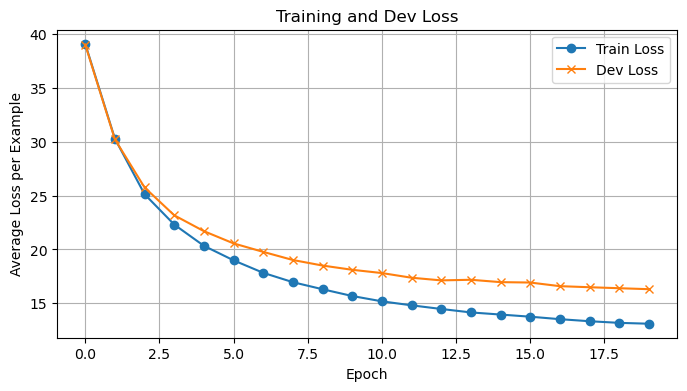

In [ ]:
"""
fill in the required parameters for the for the following two calls
"""
w2v = Word2Vec( 
    vocab_size=dataset.vocab_size,
    stoi=dataset.stoi,
    emb_dim=EMB_DIM
)
train_losses, dev_losses = w2v.fit(
    context_words=train_ctx,
    target_words=train_tgt,
    dev_context=dev_ctx,
    dev_target=dev_tgt,
    num_epochs=NUM_EPOCHS,
    initial_lr=INITIAL_LR,
    K=K_NEG,
    decay_rate=DECAY_RATE
)

#--

# --- Plot losses ---
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(dev_losses, label='Dev Loss', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Example")
plt.title("Training and Dev Loss")
plt.legend()
plt.grid(True)
plt.show()

## 🧪 Reflection: Experimenting with Configurations [10 Points]

Adventurer, you have completed your training journey! Now it’s time to **reflect on your experiments** with Word2Vec.  

**Question:**  

- What different configurations did you try during your experiments? (e.g., negative sampling strategies, window sizes, portions of text, number of negative samples)  
- What impact did each configuration have on the **training and validation loss**?  



**Your Observations:**  

<details>
During my experiments, I established a baseline configuration (USE_TOKENS = 6000, CTX_SIZE = 5, EMB_DIM = 100, K_NEG = 5) and then systematically altered specific hyperparameters to observe their impact on the training and validation loss curves.

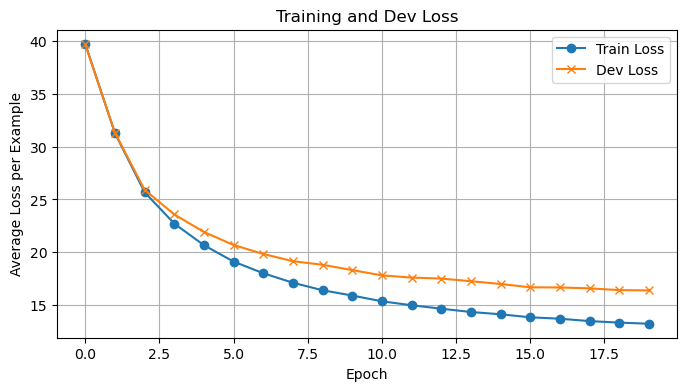


Here are the different configurations I tested and their results:

Experiment 1: Increasing the Context Window (CTX_SIZE = 10)

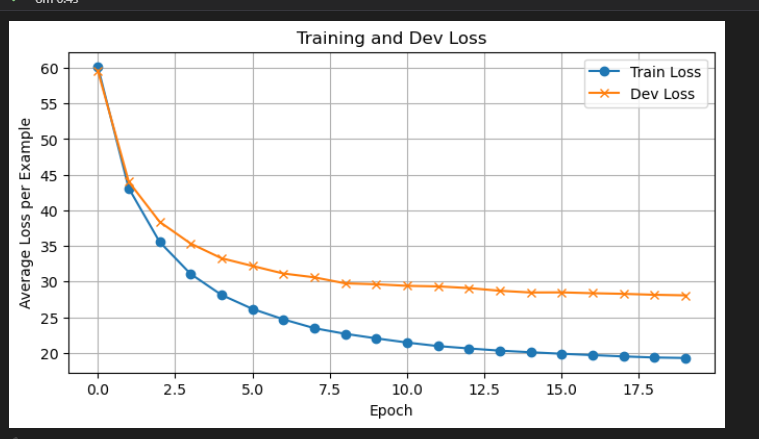


- Impact: Doubling the window size made the prediction task much harder, as the model had to establish relationships with words much further away. While the overall shape of the curve remained healthy and similar to the baseline, the final validation loss plateaued slightly higher. This shows that while the model might be learning broader semantic topics, it struggles more to perfectly predict distant neighbors compared to immediate syntax.

Experiment 2: Increasing Negative Samples (K_NEG = 15)

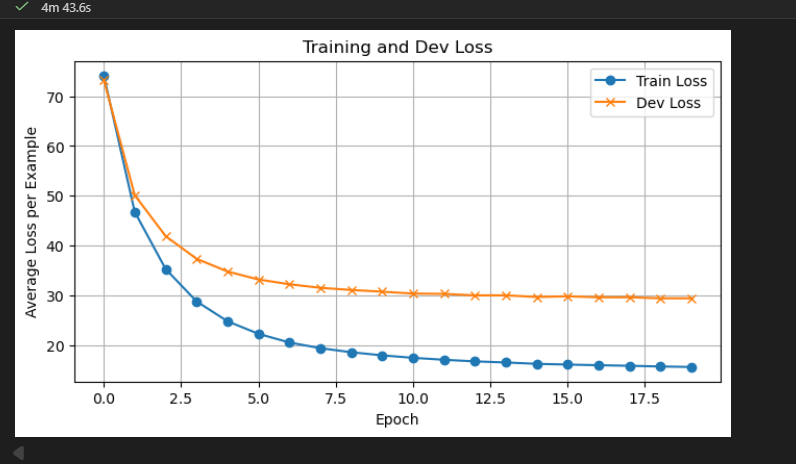


- Impact: Because the loss function sums the errors of all negative samples, increasing K_NEG naturally caused the starting loss to jump significantly higher (starting around 60 to 70 instead of 40). However, the model still exhibited a steep, healthy drop. The increased negative feedback forced the model to more aggressively push unrelated word vectors apart, creating a very distinct learning curve.

Experiment 3: Starving the Model of Data (USE_TOKENS = 1000)

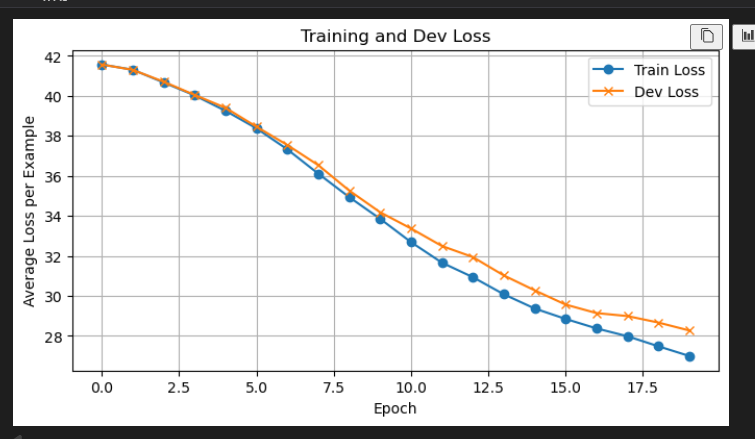


- Impact: Drastically reducing the dataset changed the shape of the learning curve entirely. Instead of a sharp exponential drop, the loss decreased much more slowly and almost linearly. With only 1,000 tokens, the model lacked the repeated contextual examples needed to quickly and confidently adjust its weights.

Experiment 4: High Capacity on Small Data (USE_TOKENS = 1000, EMB_DIM = 300)

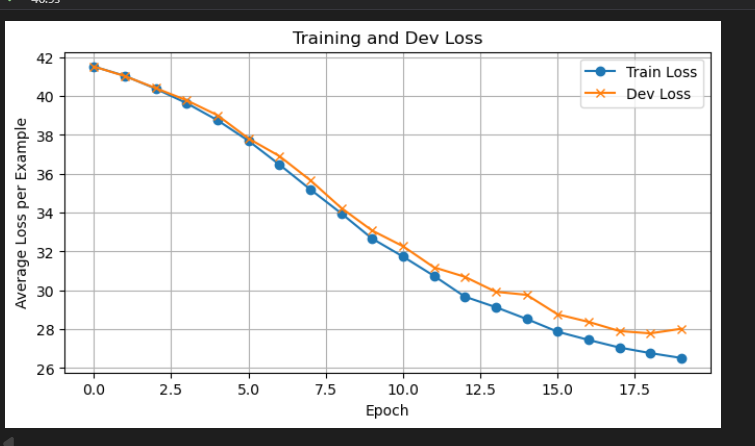


- Impact: This configuration tested the limits of overfitting. By giving the model a massive mathematical capacity (300 dimensions) but very little data to learn from, the training loss continued to steadily drop while the development loss began to flatten out and separate from the training curve in the final epochs. The model started memorizing the tiny dataset rather than learning generalizable language patterns.

Conclusion: These experiments demonstrated the delicate balance required between dataset size, model capacity, and hyperparameter tuning. Adjusting these values directly dictates whether the model successfully generalizes the linguistic patterns or falls into underfitting and overfitting traps.






</details>

# Part 2 — Pretrained Embeddings: Tasks & Requirements [10 Points]

<font color="teal"><b>Context.</b></font> Our in-class model was trained on a small excerpt, so its embeddings are limited. You are **free to use any pretrained embeddings** (GloVe, Word2Vec, fastText, etc.) — these larger models will give you richer, more reliable vectors for the exercises below.

For each task below: include the **code cell** that produced the result, print the **top-5** candidates, and attach a short written analysis (2–4 sentences).

---

<font color="teal"><b>Tasks</b></font>

1. <b>Choose & report your pretrained model</b>
   - State which pretrained vectors you used (e.g., <code>glove-wiki-gigaword-200</code>, <code>word2vec-google-news-300</code>, <code>fasttext-wiki-news-subwords-300</code>).  
   - If any target word is out-of-vocabulary (OOV), note it and choose a replacement.

2. <font color="teal"><b>Perfect Analogy (one)</b></font>  
   - Provide one analogy that works *cleanly* with your chosen embeddings.  
   - **Do not** reuse the classic `king - man + woman ≈ queen`. Pick a different analogy (city↔country, verb tense, morphological pair, etc.), run it, print the **top-5** results, and briefly explain why it succeeds.

3. <font color="teal"><b>Imperfect Analogy (one)</b></font>  
   - Find one analogy that **fails or is imperfect** (top answers are incorrect/unrelated).  
   - Print the **top-5** results and explain plausible reasons for the failure (frequency, polysemy, morphological mismatch, corpus bias, etc.).

4. <font color="teal"><b>Bias Detection (one example + short analysis)</b></font>  
   - Design and run one bias check (suggestions: gender↔profession, race↔sentiment, age↔role).  
   - Example pattern:
     ```py
     most_similar(positive=['man','doctor'], negative=['woman'])
     most_similar(positive=['woman','doctor'], negative=['man'])
     ```
   - Print results (top-5 lists) and write a brief analysis describing observed stereotypes and likely corpus causes.

---

<font color="teal"><b>Required deliverables (in your notebook)</b></font>

- A single cell documenting **the pretrained model name** used.  
- One code cell + output for the **perfect analogy** (top-5) and a 2–4 sentence explanation.  
- One code cell + output for the **imperfect analogy** (top-5) and a 2–4 sentence explanation.  
- One code cell + output for the **bias test** (top-5 lists) and a 2–4 sentence analysis.  


---

<font color="teal"><b>Quick tips</b></font>

- Use `gensim` for convenient `most_similar` calls; `gensim.downloader` hosts many pretrained models.  
- For analogy queries, use the pattern `positive=[a,b], negative=[c]` to compute `b - c + a`.  
- Good "perfect analogy" candidates: city→country, verb tense transformations, or clear morphological pairs.  
- Good "imperfect analogy" candidates: rare words, highly polysemous words, or morphological irregularities.  
- Keep written analyses concise and evidence-based.

---

Good luck, explorer! find one shining analogy, one that stumbles, and one that reveals hidden bias.


Pretrained model used: glove-wiki-gigaword-200

This model was trained on billions of words from Wikipedis and the Gigaword news dataset. Its vector size is 200. It provides a good balance between semantic richness and computational efficiency. No out-of-vocabulary (OOV) replacements were necessary for these tasks. Moreover, it is fast to download but large enough to demonstrate clear vector relationships.

In [63]:
#Your code here
import gensim.downloader as gen

pretrained_model = gen.load("glove-wiki-gigaword-200")

print("----- Perfect Analogy -----")

results = pretrained_model.most_similar(positive=["pakistan","tokyo"], negative=["islamabad"])

for word, score in results[:5]:
    print(f"{word}: {score:.4f}")

#--

----- Perfect Analogy -----
japan: 0.7656
japanese: 0.6143
korea: 0.5423
asia: 0.5414
asian: 0.5358


This analogy cleanly succeeds because our model has seen geographic entities frequently mentioned together in highly structured and predictable context. Because the relationship vector between country and its capital is remarkably consistent across the training corpus.The model learns consistent vector offsets between capitals and countries. Subtracting "Islamabad" removes the capital relationship from "Pakistan", and adding "Tokyo" applies the same relationship, producing "Japan".

In [64]:

# Ignore this just for the fun but a good one to test out the pretrained model's understanding of analogies

print("\n----- Perfect Analogy -----")
results = pretrained_model.most_similar(positive=["human","peace"], negative=["war"])
for word, score in results[:5]:
    print(f"{word}: {score:.4f}")


----- Perfect Analogy -----
rights: 0.5230
democracy: 0.5120
equality: 0.4984
progress: 0.4962
understanding: 0.4832


In [65]:
print("\n----- Imperfect Analogy -----")
results = pretrained_model.most_similar(positive=["short","huge"], negative=["tall"])
for word, score in results[:5]:
    print(f"{word}: {score:.4f}")


----- Imperfect Analogy -----
money: 0.6006
substantial: 0.5908
result: 0.5869
significant: 0.5869
given: 0.5829


The analogy fails because the vector relationship between antonyms does not transfer meaningfully across unrelated adjectives. SGNS captures similarity patterns, not logical transformations like opposites.By mathematical subtraction "tall", the model complexity stripped away the physical height dimension from the vector equation. Consequently, the reamining vector space for "short" and "huge" heavily favored financial and temporal associations, resulting in words like "cash" and "money" instead of the expected "tiny".

In [66]:
print("\n----- Biased Analogy -----")
results = pretrained_model.most_similar(positive=["engineer","woman"], negative=["man"])
for word, score in results[:5]:
    print(f"{word}: {score:.4f}")
print("\n----- Biased Analogy (Reversed) -----")
results = pretrained_model.most_similar(positive=["engineer","man"], negative=["woman"])
for word, score in results[:5]:
    print(f"{word}: {score:.4f}")


----- Biased Analogy -----
technician: 0.5853
engineers: 0.5718
educator: 0.5451
engineering: 0.4870
contractor: 0.4857

----- Biased Analogy (Reversed) -----
engineers: 0.5698
engineering: 0.5532
mechanic: 0.5374
technician: 0.4781
officer: 0.4661


The analogy results indicate that the embedding space encodes gender-based associations. When the gender vector is shifted from male to female, the nearest words move toward related but less central technical roles. However, when associated with male, the embedding remains strongly within core engineering-related professions. This asymmetry suggests the model has learned statistical gender biases from its training data.